<a href="https://colab.research.google.com/github/charfx/learning_pytorch_deep_learning/blob/main/first_steps_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [83]:
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [8]:
mu_list=[1,2,3,4,5]

In [9]:
onees=np.ones(shape=(4,5))

# Tensor :
  

In [25]:
tensor_2d=torch.randn(3,4)

In [26]:
tensor_2d

tensor([[ 0.0350, -0.0161,  1.6530,  2.3174],
        [-1.1719,  0.0830,  0.0377, -1.2984],
        [-0.2830, -1.9745, -1.4212, -0.9065]])

In [27]:
tensor_2d.type()

'torch.FloatTensor'

In [28]:
#creating of tensor based of the numpy array

second_t=torch.tensor(onees)

In [40]:
mytorch=torch.arange(15)
mytorch.size()

torch.Size([15])

In [42]:
mytorch_reshaped=mytorch.reshape(3,5)
mytorch_reshaped

tensor([[ 0,  1,  2,  3,  4],
        [ 5,  6,  7,  8,  9],
        [10, 11, 12, 13, 14]])

In [43]:
mytorch_reshaped.shape

torch.Size([3, 5])

# Some Maths with torch

In [45]:
tensor_a=torch.tensor([1,2,3,4,5])
tensor_b=torch.tensor([1,2,3,4,5])

In [52]:
tensor_z=tensor_a * tensor_b
tensor_z

tensor([ 1,  4,  9, 16, 25])

In [53]:
torch.add(tensor_a,tensor_b)

tensor([ 2,  4,  6,  8, 10])

In [60]:
torch.var(tensor_a.float())

tensor(2.5000)

# first neural network

In [68]:
#creation of model clas that inherits nn.Module
class Model(nn.Module):
  def __init__(self,in_feature=4,H1=8,H2=9,out_feature=3):
    super().__init__()
    self.fc1=nn.Linear(in_feature,H1)
    self.fc2=nn.Linear(H1,H2)
    self.out=nn.Linear(H2,out_feature)
  def forward(self,x):
    x=F.relu(self.fc1(x))
    x=F.relu(self.fc2(x))
    x=self.out(x)
    return x

In [69]:
torch.manual_seed(41)
model=Model()

In [73]:
# To display the model structure in PyTorch, simply print the model object.
print(model)

Model(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=9, bias=True)
  (out): Linear(in_features=9, out_features=3, bias=True)
)


In [93]:
from google.colab import files
files.upload()

Saving iris.csv to iris (1).csv


{'iris (1).csv': b'sepal_length,sepal_width,petal_length,petal_width,species\n5.1,3.5,1.4,0.2,setosa\n4.9,3.0,1.4,0.2,setosa\n4.7,3.2,1.3,0.2,setosa\n4.6,3.1,1.5,0.2,setosa\n5.0,3.6,1.4,0.2,setosa\n5.4,3.9,1.7,0.4,setosa\n4.6,3.4,1.4,0.3,setosa\n5.0,3.4,1.5,0.2,setosa\n4.4,2.9,1.4,0.2,setosa\n4.9,3.1,1.5,0.1,setosa\n5.4,3.7,1.5,0.2,setosa\n4.8,3.4,1.6,0.2,setosa\n4.8,3.0,1.4,0.1,setosa\n4.3,3.0,1.1,0.1,setosa\n5.8,4.0,1.2,0.2,setosa\n5.7,4.4,1.5,0.4,setosa\n5.4,3.9,1.3,0.4,setosa\n5.1,3.5,1.4,0.3,setosa\n5.7,3.8,1.7,0.3,setosa\n5.1,3.8,1.5,0.3,setosa\n5.4,3.4,1.7,0.2,setosa\n5.1,3.7,1.5,0.4,setosa\n4.6,3.6,1.0,0.2,setosa\n5.1,3.3,1.7,0.5,setosa\n4.8,3.4,1.9,0.2,setosa\n5.0,3.0,1.6,0.2,setosa\n5.0,3.4,1.6,0.4,setosa\n5.2,3.5,1.5,0.2,setosa\n5.2,3.4,1.4,0.2,setosa\n4.7,3.2,1.6,0.2,setosa\n4.8,3.1,1.6,0.2,setosa\n5.4,3.4,1.5,0.4,setosa\n5.2,4.1,1.5,0.1,setosa\n5.5,4.2,1.4,0.2,setosa\n4.9,3.1,1.5,0.1,setosa\n5.0,3.2,1.2,0.2,setosa\n5.5,3.5,1.3,0.2,setosa\n4.9,3.1,1.5,0.1,setosa\n4.4,3.0,1.

In [87]:
data=pd.read_csv('iris.csv')

In [90]:
data['species']=data['species'].replace('setosa',0.0)
data['species']=data['species'].replace('versicolor',1.0)
data['species']=data['species'].replace('virginica',2.0)

In [91]:
data

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,3.0,5.2,2.0,2.0
148,6.2,3.4,5.4,2.3,2.0


In [92]:
X=data.drop('species',axis=1).values
y=data['species'].values

In [97]:
from sklearn.model_selection import train_test_split


X_tran,X_test,Y_train,Y_test=train_test_split(X,y,test_size=0.2,random_state=41)

In [98]:
X_train=torch.FloatTensor(X_tran)
X_test=torch.FloatTensor(X_test)
Y_train=torch.LongTensor(Y_train)
Y_test=torch.LongTensor(Y_test)

In [99]:
#Optimized and model of measure and learning rate alpha

lost=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model.parameters(),lr=0.01)

In [106]:
epochs=100
losses=[]
for i in range(epochs):
#forwaring and prediction and calculating of loss and cost funtion
  y_pred=model.forward(X_train)
  loss=lost(y_pred,Y_train)
  losses.append(loss.detach().numpy())
#backprogpagation
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

In [107]:
losses

[array(1.1251551, dtype=float32),
 array(1.1095243, dtype=float32),
 array(1.0960757, dtype=float32),
 array(1.0845399, dtype=float32),
 array(1.0739157, dtype=float32),
 array(1.0637413, dtype=float32),
 array(1.0538721, dtype=float32),
 array(1.0440351, dtype=float32),
 array(1.0337213, dtype=float32),
 array(1.0227365, dtype=float32),
 array(1.0096259, dtype=float32),
 array(0.99543494, dtype=float32),
 array(0.9828447, dtype=float32),
 array(0.9664682, dtype=float32),
 array(0.9485272, dtype=float32),
 array(0.93056124, dtype=float32),
 array(0.91120327, dtype=float32),
 array(0.8891754, dtype=float32),
 array(0.86526936, dtype=float32),
 array(0.8407701, dtype=float32),
 array(0.8157406, dtype=float32),
 array(0.7899296, dtype=float32),
 array(0.7633074, dtype=float32),
 array(0.7376408, dtype=float32),
 array(0.7132112, dtype=float32),
 array(0.69020504, dtype=float32),
 array(0.6690838, dtype=float32),
 array(0.6484998, dtype=float32),
 array(0.6277524, dtype=float32),
 array(0.

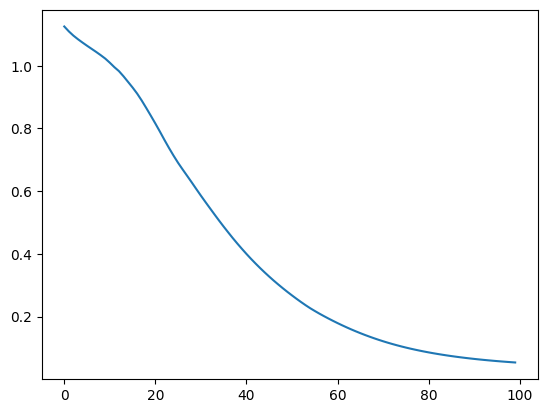

In [108]:
plt.plot(range(epochs),losses)